<a href="https://colab.research.google.com/github/dr-dlr/ENOE/blob/main/Tesis_ok.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# #Readme

---

## 1. Título de la Investigación
**"Determinantes Estructurales del Nivel Salarial en Oaxaca de Juárez: Análisis de Importancia de Atributos mediante Aprendizaje Automático Supervisado para la Optimización de Políticas Públicas."**

## 2. Planteamiento del Problema
La desigualdad salarial y la precariedad económica en el sur de México, específicamente en el municipio de Oaxaca de Juárez, han sido abordadas tradicionalmente desde perspectivas reactivas - descriptivas que no logran capturar la jerarquía de los factores que realmente detonan ingresos superiores o precarios. Siendo que desde la literatura en administración pública, se atienda a las consecuencias en vez de las causas.

En la gestión pública moderna, el diseño de intervenciones no puede basarse en supuestos lineales o simple exposición de correlaciones. Existe una brecha en la literatura administrativa regional sobre qué variables (educativas, estructurales o de gestión) tienen un mayor **peso relativo** en la determinación del ingreso. Esta tesis aborda dicha brecha utilizando algoritmos de aprendizaje automático para extraer el "valor de importancia" de cada factor, permitiendo que la administración pública estatal y municipal priorice recursos en las áreas de mayor impacto.

## 3. Justificación y Aporte Científico
El aporte central de esta investigación a las **Ciencias de la Administración** y la **Administración Pública** es la transición de una "administración intuitiva" a una **"Administración Pública Basada en Datos" (Data-Driven Public Administration)** o **Políticas Públicas Computacionales (Computational Public Policy)**.

* **Aporte Metodológico:** Se implementa un modelo de clasificación robusto que trasciende la correlación simple, utilizando el cálculo de **Importancia de Atributos (Feature Importance)** para identificar los predictores clave del nivel salarial.
* **Aporte a la Gestión:** La tabla de resultados finales servirá como un **Mapa Estratégico de Intervención**, donde cada porcentaje de importancia guiará la inversión en acciones de gobierno.

---

## 4. Marco Teórico y Variables de la Investigación
La investigación se fundamenta en la **Teoría del Capital Humano** (Becker, 1964) y la **Teoría de la Segmentación del Mercado de Trabajo** (Doeringer & Piore, 1971). Para operacionalizar estas teorías, se seleccionan variables socioeconómicas de los microdatos de la ENOE, sustentadas en el manual descriptivo de la encuesta.

### 4.1. Variable Objetivo (Target)
* **Nivel Salarial:** Se utilizará una variable sintética `ingreso_clasificado` (Clasificación de la población ocupada por nivel de ingreso), la cual segmenta el ingreso en cuartiles, proporcionado por `INGOCUP` (Ingreso mensual en pesos de los ocupados).

### 4.2. Variables Explicativas (Features)
Para obtener la tabla de importancia, se han seleccionado atributos que representan tanto el perfil del individuo como las condiciones de la unidad económica donde se desempeña:

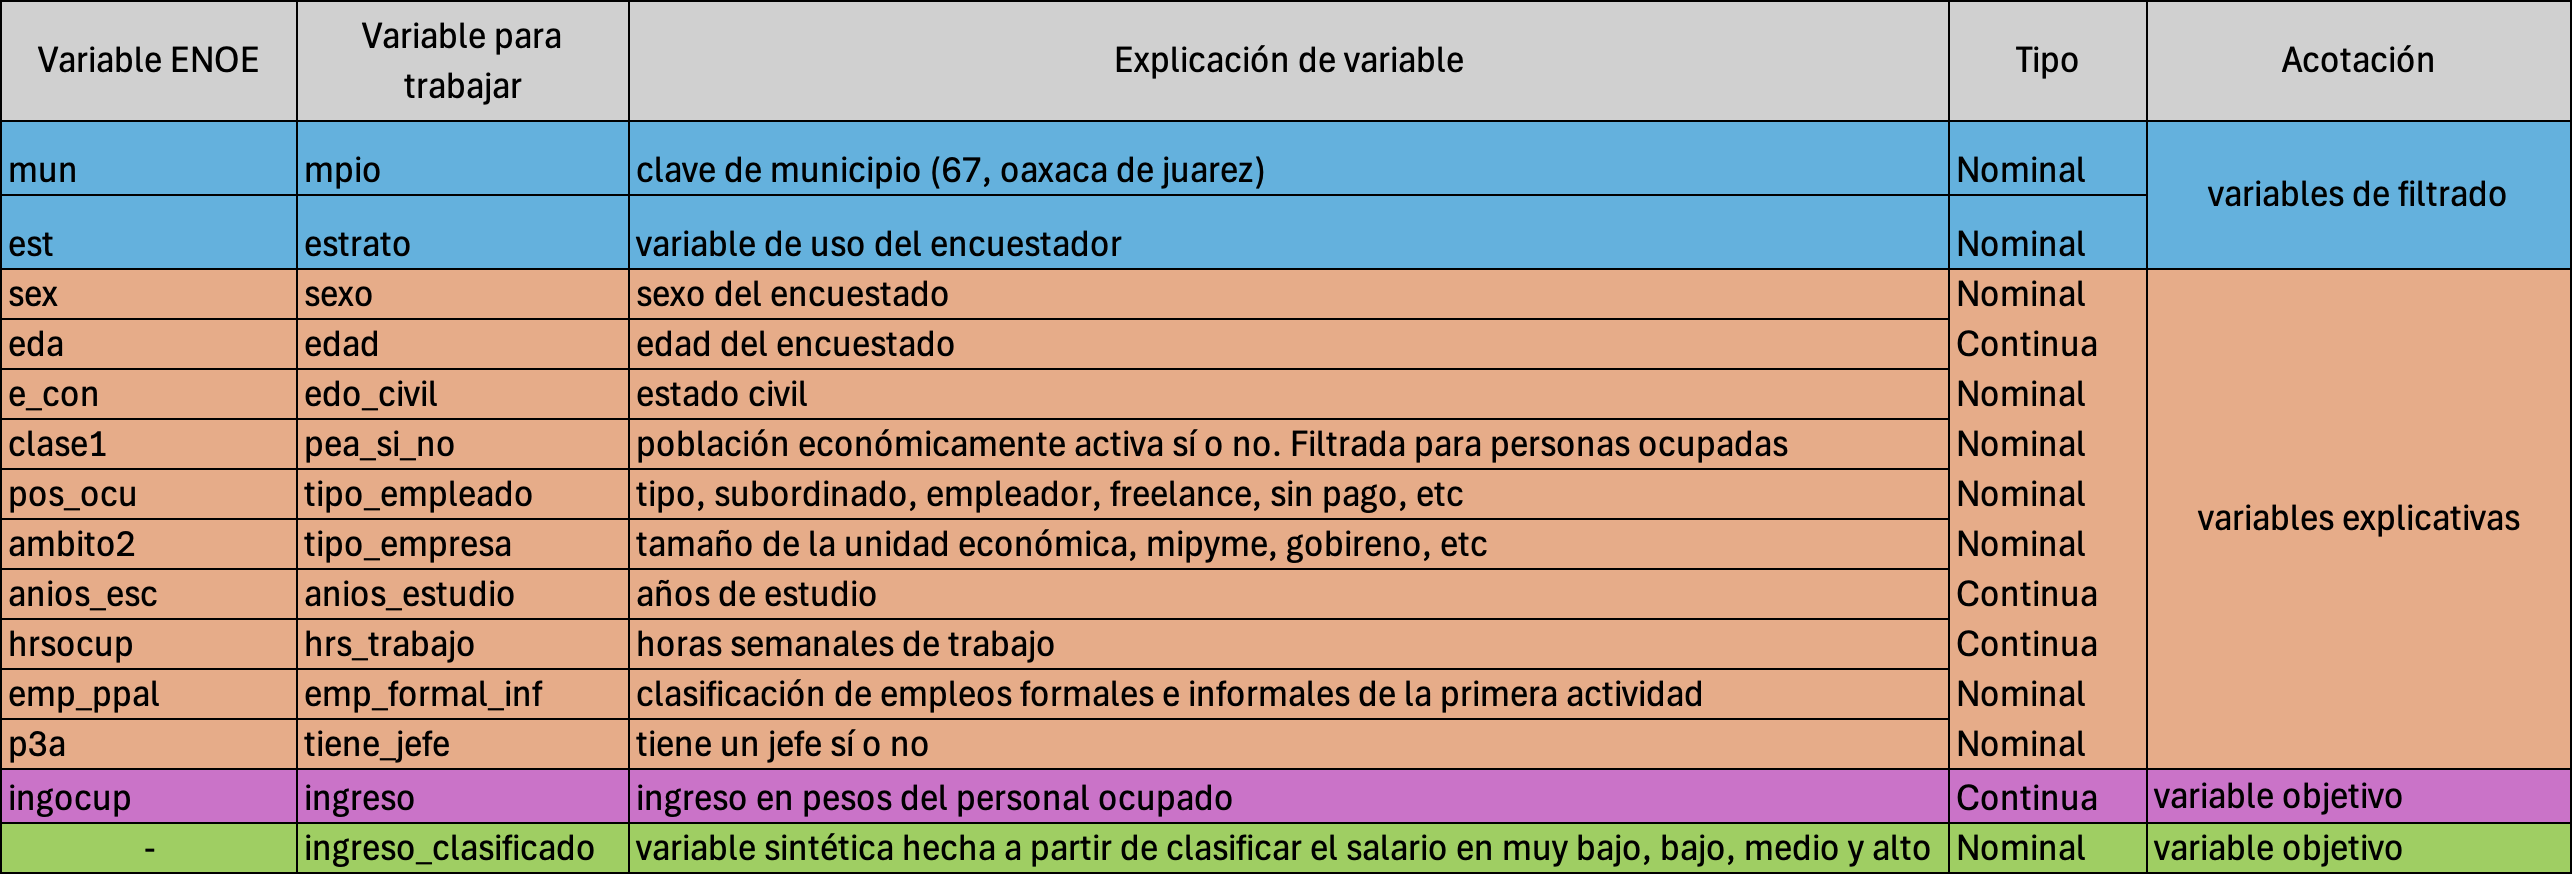

---

## 5. Estrategia Metodológica (Data Science Pipeline)
La investigación seguirá un proceso de **Aprendizaje Supervisado** para predecir si un individuo pertenece a un cuartil salarial muy bajo, bajo, medio o alto, calculando posteriormente la importancia de los predictores.

### 5.1. Selección del Modelo
Se propone el uso de **Ensembles de Árboles de Decisión (Random Forest o XGBoost)** debido a su capacidad intrínseca para manejar variables categóricas y capturar relaciones no lineales.

### 5.2. Cálculo de Feature Importance
Se utilizará el siguiente método para garantizar el rigor científico:
1.  **Gini Importance (MDI):** Para identificar qué variables reducen más la impureza en los nodos de decisión.
$$Imp(X_i) = \frac{1}{N_{trees}} \sum_{T} \Delta I(X_i, T)$$
*Ecuación: Representación conceptual de la importancia promedio de una variable en un ensamble de modelos.*

## 6. Delimitación y Alcance
* **Geográfico:** El filtrado se realizará estrictamente para la entidad **20 (Oaxaca)** y el municipio **067 (Oaxaca de Juárez)**.
* **Temporal:** Análisis longitudinal de un trimestre del año 2025, sin embargo, la investigación plantea la creación de una función que replique el pipeline original para identificar si la importancia de las variables ha cambiado en otros trimestres (por ejemplo, si la educación hoy pesa más o menos que el periodo anterior ante la automatización).

## 7. Impacto en Políticas Públicas
El producto final será una **Matriz de Priorización Gubernamental**. Si el modelo indica que el tamaño de la empresa tiene un peso del 40% frente a un 10% de los años de estudios, la política pública debería enfocarse en el escalamiento de micronegocios hacia la formalidad, más que únicamente en la oferta educativa tradicional, logrando así una administración eficiente de los recursos estatales.

---

In [ ]:
# IMPORTANDO LIBS
import pandas as pd
import numpy as np
import seaborn as sns

# ETL

In [ ]:
# CARGA EL DATASET
enoe = pd.read_csv('/content/enoe_final.csv')
enoe.head(1)

,mpio,estrato,sexo,edad,edo_civil,pea_si_no,tipo_empleado,tipo_empresa,anios_estudio,hrs_trabajo,ingreso,emp_formal_inf,tiene_jefe
0,67,30,1,41,5,1,1,5,12,60,0,2,1.0


In [ ]:
# CORRIGE EL TIPO DE DATO EN tiene_jefe
enoe['tiene_jefe'] = pd.to_numeric(enoe['tiene_jefe'], errors='coerce').astype('Int64')

In [ ]:
enoe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1363 entries, 0 to 1362
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   mpio            1363 non-null   int64
 1   estrato         1363 non-null   int64
 2   sexo            1363 non-null   int64
 3   edad            1363 non-null   int64
 4   edo_civil       1363 non-null   int64
 5   pea_si_no       1363 non-null   int64
 6   tipo_empleado   1363 non-null   int64
 7   tipo_empresa    1363 non-null   int64
 8   anios_estudio   1363 non-null   int64
 9   hrs_trabajo     1363 non-null   int64
 10  ingreso         1363 non-null   int64
 11  emp_formal_inf  1363 non-null   int64
 12  tiene_jefe      1334 non-null   Int64
dtypes: Int64(1), int64(12)
memory usage: 139.9 KB


In [ ]:
# CORRECIÓN DE LOS 29 NULOS EN tiene_jefe
moda = enoe['tiene_jefe'].mode()[0]
enoe['tiene_jefe'] = enoe['tiene_jefe'].fillna(moda)

In [ ]:
# COMPROBANDO EXISTENCIA DE NULOS
print(enoe.isnull().sum())

mpio              0
estrato           0
sexo              0
edad              0
edo_civil         0
pea_si_no         0
tipo_empleado     0
tipo_empresa      0
anios_estudio     0
hrs_trabajo       0
ingreso           0
emp_formal_inf    0
tiene_jefe        0
dtype: int64


In [ ]:
# 2. Imputación de años de estudio
# Calculamos el promedio SOLO de las personas que NO tienen 99
promedio_real = enoe[enoe['anios_estudio'] != 99]['anios_estudio'].mean()

# Redondeamos porque no existen "11.82 años", es un número entero de ciclos escolares
promedio_redondeado = round(promedio_real)

# Reemplazamos los 99 con el valor redondeado (12)
enoe.loc[enoe['anios_estudio'] == 99, 'anios_estudio'] = promedio_redondeado

In [ ]:
# DEPURACIÓN DE OTRAS VARIABLES DE FILTRADO Y SIN USO
enoe = enoe.drop(columns=['mpio', 'estrato', 'pea_si_no'], axis = 1)

In [ ]:
enoe.head(1)

,sexo,edad,edo_civil,tipo_empleado,tipo_empresa,anios_estudio,hrs_trabajo,ingreso,emp_formal_inf,tiene_jefe
0,1,41,5,1,5,12,60,0,2,1


In [ ]:
# ESTADÍSTICAS DESCRIPTIVAS
enoe.describe().round(1)

,sexo,edad,edo_civil,tipo_empleado,tipo_empresa,anios_estudio,hrs_trabajo,ingreso,emp_formal_inf,tiene_jefe
count,1363.0,1363.0,1363.0,1363.0,1363.0,1363.0,1363.0,1363.0,1363.0,1363.0
mean,1.5,41.9,4.3,1.5,3.5,11.8,39.1,5239.3,1.4,1.3
std,0.5,14.3,2.0,0.9,2.3,4.4,18.8,6713.7,0.5,0.5
min,1.0,14.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
25%,1.0,31.0,2.0,1.0,2.0,9.0,28.0,0.0,1.0,1.0
50%,1.0,41.0,5.0,1.0,3.0,12.0,40.0,2150.0,1.0,1.0
75%,2.0,52.0,6.0,2.0,5.0,17.0,48.0,8600.0,2.0,2.0
max,2.0,83.0,6.0,3.0,8.0,21.0,98.0,55000.0,2.0,2.0


In [ ]:
# CORRELACIÓN DE VARIABLES VS LA OBJETIVO
enoe.corr()['ingreso'].sort_values(ascending = False)

,ingreso
ingreso,1.000000
emp_formal_inf,0.186252
hrs_trabajo,0.138402
tipo_empresa,0.124445
anios_estudio,0.101280
edad,-0.028531
tipo_empleado,-0.065429
tiene_jefe,-0.069785
edo_civil,-0.080009
sexo,-0.083520


# BREVE ANÁLISIS EXPLORATORIO

In [ ]:
# PREPARANDO VARIABLES CATEGÓRICAS
enoe['sexo'] = enoe['sexo'].replace({1: 'Hombres', 2: 'Mujeres'})
enoe['edo_civil'] = enoe['edo_civil'].replace({1: 'Vive con pareja', 2: 'Separados', 3: 'Divorciados', 4: 'Viudos', 5: 'Casados', 6: 'Solteros'})
enoe['tipo_empleado'] = enoe['tipo_empleado'].replace({0: 'No aplica', 1: 'Subordinados', 2: 'Empleadores', 3: 'Autónomos', 5: 'No especificado'})
enoe['tipo_empleado'] = enoe['tipo_empleado'].replace({0: 'No aplica', 1: 'Subordinados', 2: 'Empleadores', 3: 'Autónomos', 5: 'No especificado'})
enoe['tipo_empresa'] = enoe['tipo_empresa'].replace({0: 'No aplica', 1: 'Micronegocios (2 + 3)', 2: 'Sin establecimiento', 3: 'Con establecimiento', 4: 'Pequeños establecimientos', 5: 'Medianos establecimientos', 6: 'Grandes establecimientos', 7: 'Gobierno', 8: 'Otros'})
enoe['emp_formal_inf'] = enoe['emp_formal_inf'].replace({0: 'No aplica', 1: 'Informalidad laboral', 2: 'Formalidad laboral'})
enoe['tiene_jefe'] = enoe['tiene_jefe'].astype(str).replace({1: 'Tiene un jefe', 2: 'No tiene un jefe'})

In [ ]:
enoe.head(2)

,sexo,edad,edo_civil,tipo_empleado,tipo_empresa,anios_estudio,hrs_trabajo,ingreso,emp_formal_inf,tiene_jefe
0,Hombres,41,Casados,Subordinados,Medianos establecimientos,12,60,0,Formalidad laboral,1
1,Hombres,29,Vive con pareja,Subordinados,Con establecimiento,17,28,8000,Formalidad laboral,1


In [ ]:
import warnings
warnings.filterwarnings('ignore')

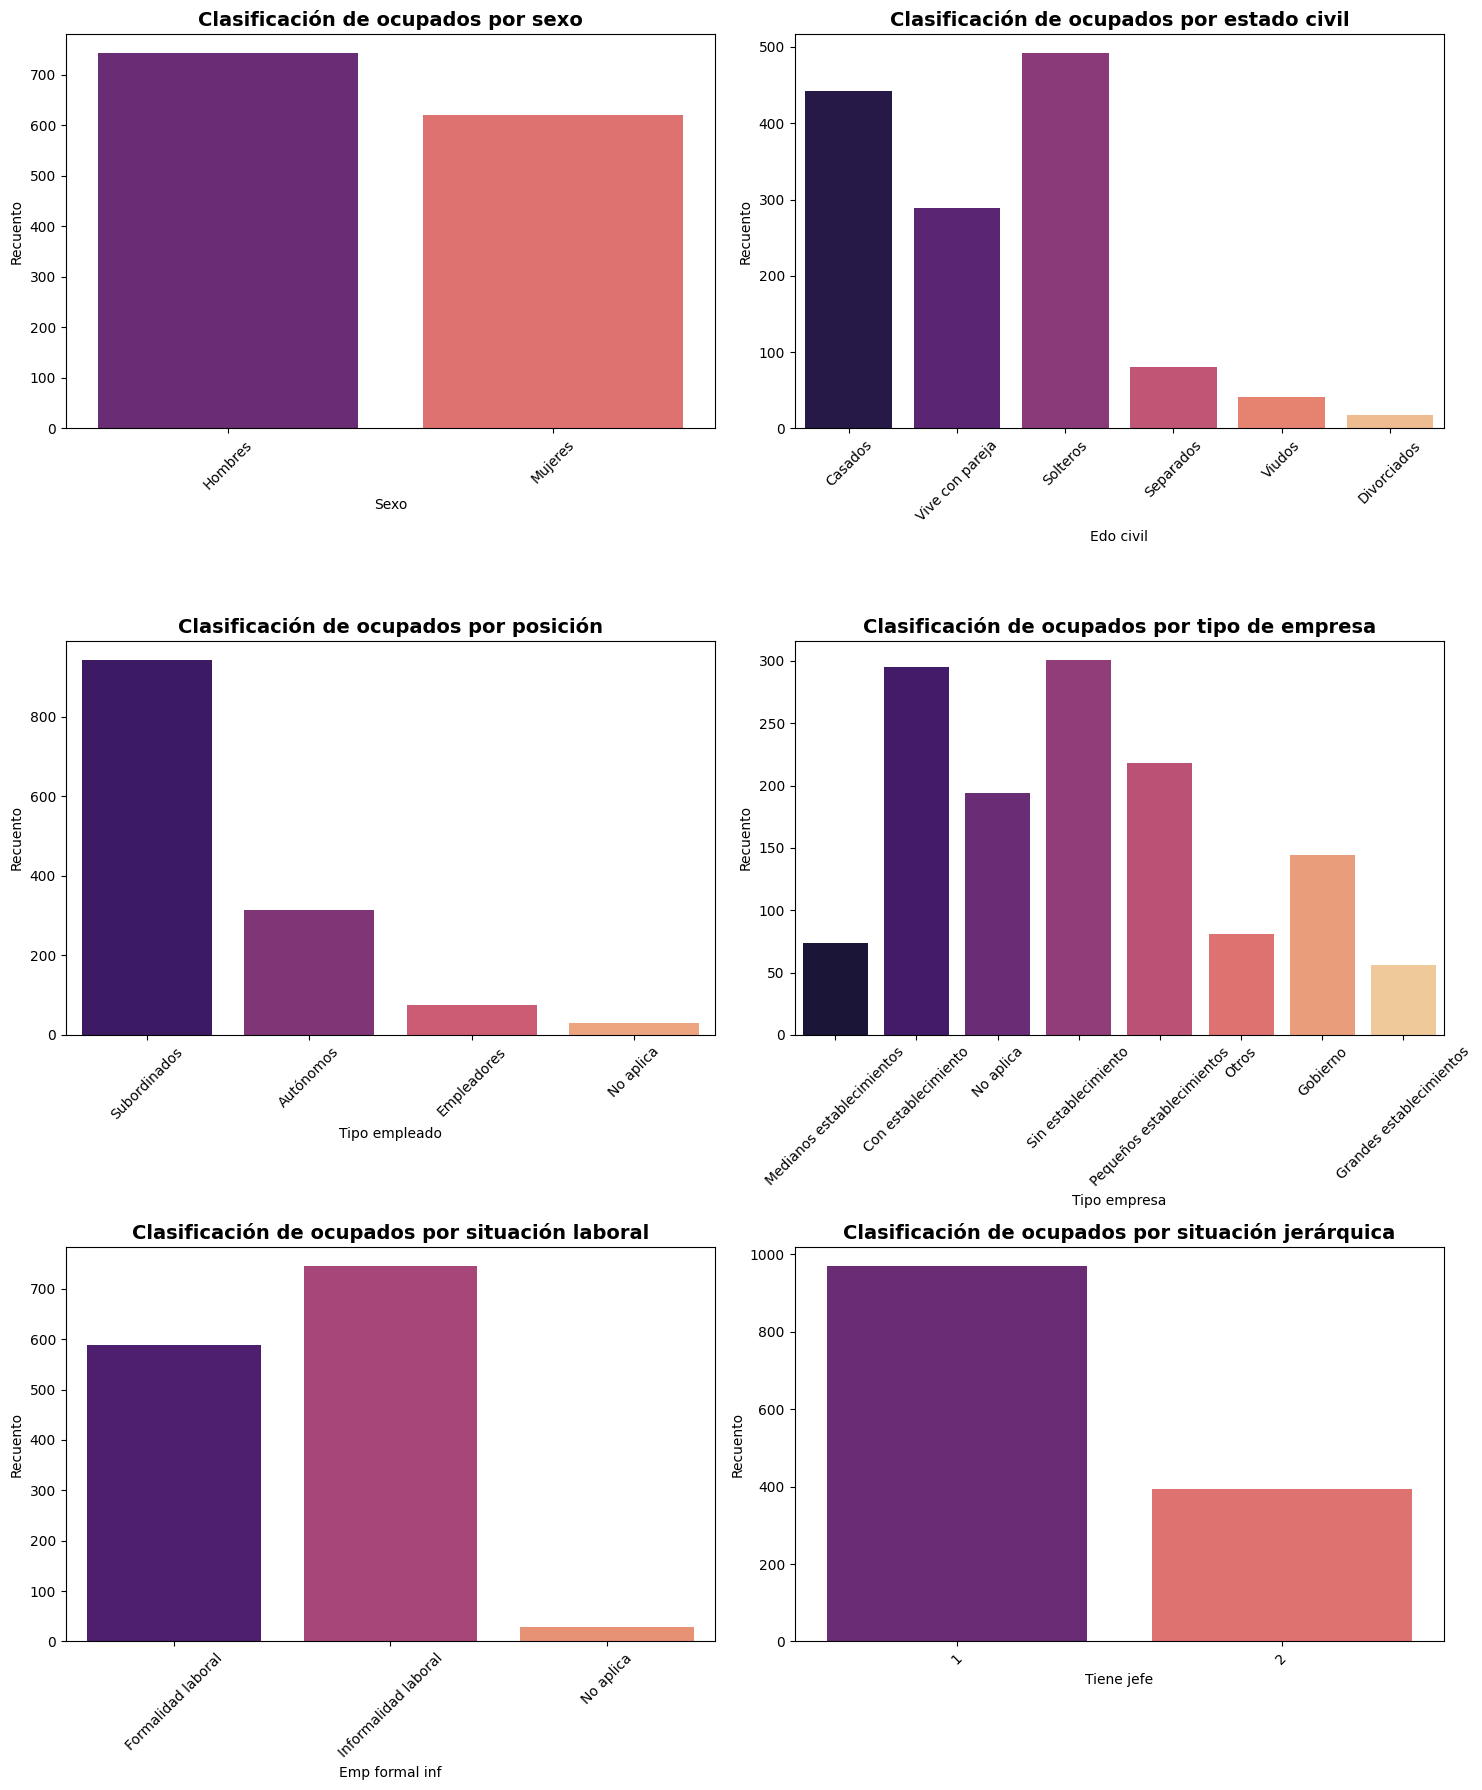

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plots_config = [
    ('sexo', 'Clasificación de ocupados por sexo'),
    ('edo_civil', 'Clasificación de ocupados por estado civil'),
    ('tipo_empleado', 'Clasificación de ocupados por posición'),
    ('tipo_empresa', 'Clasificación de ocupados por tipo de empresa'),
    ('emp_formal_inf', 'Clasificación de ocupados por situación laboral'),
    ('tiene_jefe', 'Clasificación de ocupados por situación jerárquica')
]

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(15, 18))
axes = axes.flatten()  # Aplanamos la matriz de ejes para iterar fácilmente

for i, (col, title) in enumerate(plots_config):
    sns.countplot(x=col, data=enoe, ax=axes[i], palette='magma')

    axes[i].set_title(title, fontsize=14, fontweight='bold')
    axes[i].set_ylabel('Recuento')
    axes[i].set_xlabel(col.replace('_', ' ').capitalize())

    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show();

# MODELANDO

In [ ]:
# CREA LA NUEVA VARIABLE DE SALARIO

import numpy as np
import pandas as pd

# Crear columna
enoe['ingreso_clasificado'] = np.nan

# Separar ingresos positivos
ingresos_pos = enoe.loc[enoe['ingreso'] > 0, 'ingreso']

# Calcular percentiles (puedes ajustar estos cortes si quieres más fineza)
p33 = ingresos_pos.quantile(0.33)
p66 = ingresos_pos.quantile(0.66)

# Asignar categorías

# sin ingreso
enoe.loc[enoe['ingreso'] == 0, 'ingreso_clasificado'] = 0

# ingreso bajo
enoe.loc[(enoe['ingreso'] > 0) & (enoe['ingreso'] <= p33), 'ingreso_clasificado'] = 1

# ingreso medio
enoe.loc[(enoe['ingreso'] > p33) & (enoe['ingreso'] <= p66), 'ingreso_clasificado'] = 2

# ingreso alto
enoe.loc[enoe['ingreso'] > p66, 'ingreso_clasificado'] = 3

# convertir a entero
enoe['ingreso_clasificado'] = enoe['ingreso_clasificado'].astype(int)

In [ ]:
#COMPRUEBA LA EXISTENCIA

enoe.columns

Index(['sexo', 'edad', 'edo_civil', 'tipo_empleado', 'tipo_empresa',
       'anios_estudio', 'hrs_trabajo', 'ingreso', 'emp_formal_inf',
       'tiene_jefe', 'ingreso_clasificado'],
      dtype='object')

In [ ]:
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder
from imblearn.over_sampling import SMOTE

In [ ]:
#ASIGNACIÓN DE VARIABLE OBJETIVO Y EXPLICATIVAS

X = enoe.drop(['ingreso_clasificado', 'ingreso'], axis = 1)
y = enoe['ingreso_clasificado']

In [ ]:
# enoe.to_csv('enoe_prueba.csv', index = False)

In [ ]:
# 4. One-Hot Encoding (Traducción de texto a matemáticas)
columnas_categoricas = ['sexo', 'edo_civil', 'tipo_empleado', 'tipo_empresa', 'emp_formal_inf']

# get_dummies crea las nuevas columnas binarias.
# drop_first=True es crucial para evitar la multicolinealidad perfecta.
X_procesado = pd.get_dummies(X, columns=columnas_categoricas, drop_first=True).astype(int)

print(f"La matriz X pasó de {X.shape[1]} a {X_procesado.shape[1]} columnas.")

La matriz X pasó de 9 a 22 columnas.


In [ ]:
X_procesado.columns

Index(['edad', 'anios_estudio', 'hrs_trabajo', 'tiene_jefe', 'sexo_Mujeres',
       'edo_civil_Divorciados', 'edo_civil_Separados', 'edo_civil_Solteros',
       'edo_civil_Viudos', 'edo_civil_Vive con pareja',
       'tipo_empleado_Empleadores', 'tipo_empleado_No aplica',
       'tipo_empleado_Subordinados', 'tipo_empresa_Gobierno',
       'tipo_empresa_Grandes establecimientos',
       'tipo_empresa_Medianos establecimientos', 'tipo_empresa_No aplica',
       'tipo_empresa_Otros', 'tipo_empresa_Pequeños establecimientos',
       'tipo_empresa_Sin establecimiento',
       'emp_formal_inf_Informalidad laboral', 'emp_formal_inf_No aplica'],
      dtype='object')

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import pandas as pd

X_train, X_test, y_train, y_test = train_test_split(X_procesado, y, test_size=0.2, random_state=42)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train) # Aquí ocurre la magia del aprendizaje

y_pred = rf_model.predict(X_test)
precision = accuracy_score(y_test, y_pred)

print(f"Precisión del modelo en datos no vistos: {precision:.4f}")

Precisión del modelo en datos no vistos: 0.4615


In [ ]:
importancias = rf_model.feature_importances_
nombres_variables = X_procesado.columns

tabla_importancia = pd.DataFrame({
    'Variable': nombres_variables,
    'Peso_Predictivo': importancias
})

tabla_importancia = tabla_importancia.sort_values(by='Peso_Predictivo', ascending=False)

print("--- TOP 10 PREDICTORES DEL NIVEL DE INGRESO ---")
print(tabla_importancia.head(10))

--- TOP 10 PREDICTORES DEL NIVEL DE INGRESO ---
                                  Variable  Peso_Predictivo
0                                     edad         0.256003
2                              hrs_trabajo         0.243797
1                            anios_estudio         0.144615
20     emp_formal_inf_Informalidad laboral         0.044293
4                             sexo_Mujeres         0.044126
7                       edo_civil_Solteros         0.035600
9                edo_civil_Vive con pareja         0.034185
19        tipo_empresa_Sin establecimiento         0.027539
16                  tipo_empresa_No aplica         0.024112
18  tipo_empresa_Pequeños establecimientos         0.021156


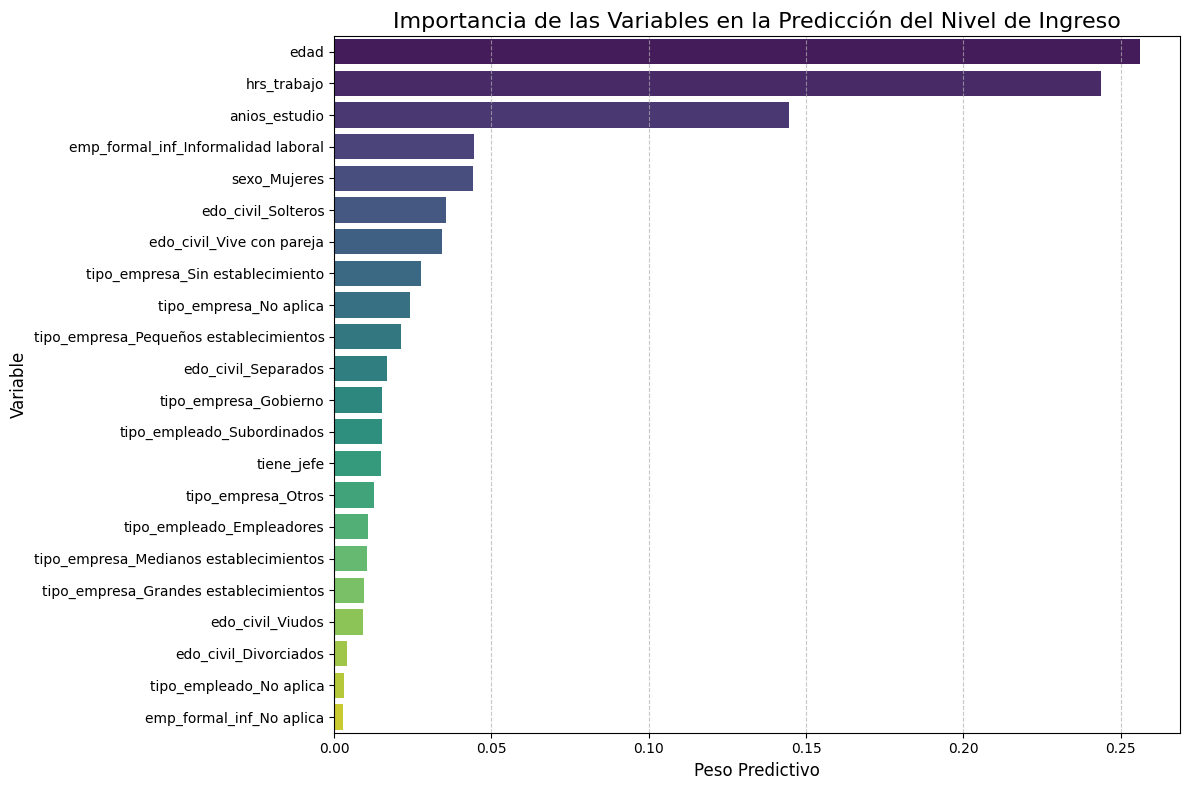

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))
sns.barplot(x='Peso_Predictivo', y='Variable', data=tabla_importancia, palette='viridis')
plt.title('Importancia de las Variables en la Predicción del Nivel de Ingreso', fontsize=16)
plt.xlabel('Peso Predictivo', fontsize=12)
plt.ylabel('Variable', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

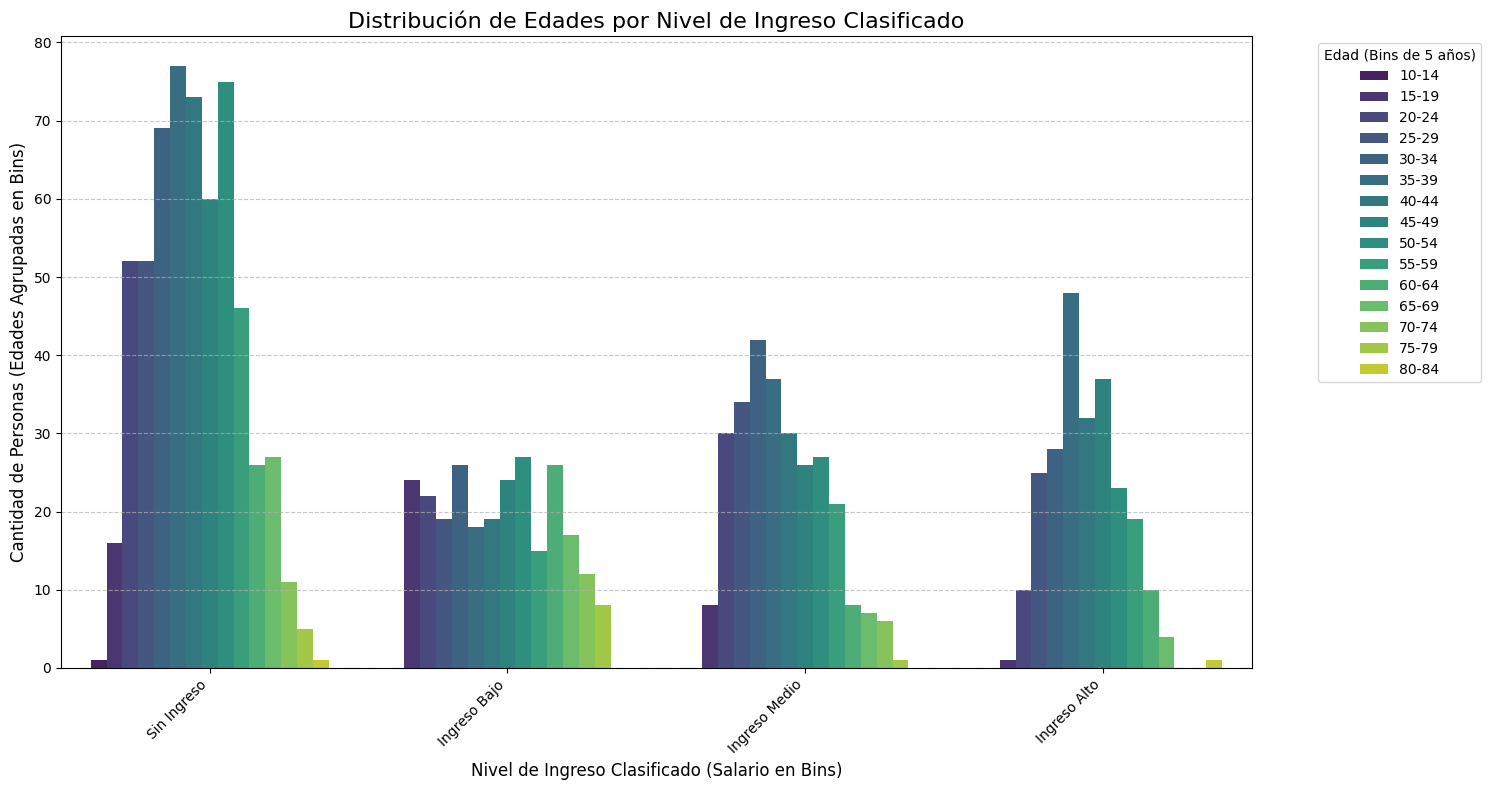

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Crear bins para la edad (de 5 en 5 años)
# Asegúrate de que los bins cubran todo el rango de edad
bins_edad = range(0, enoe['edad'].max() + 6, 5) # +6 para asegurar que el último bin incluya la edad máxima
labels_edad = [f'{i}-{i+4}' for i in range(0, enoe['edad'].max() + 5, 5)]
enoe['edad_binned'] = pd.cut(enoe['edad'], bins=bins_edad, right=False, labels=labels_edad[:len(bins_edad)-1])

# 2. Asegurarse de que las etiquetas de ingreso clasificado existan
# (se definieron en la celda 16717526, pero se redefinen para robustez)
income_labels = {0: 'Sin Ingreso', 1: 'Ingreso Bajo', 2: 'Ingreso Medio', 3: 'Ingreso Alto'}
enoe['ingreso_clasificado_label'] = enoe['ingreso_clasificado'].map(income_labels)

# 3. Crear el gráfico de barras (countplot es ideal para mostrar conteos de categorías binned)
plt.figure(figsize=(15, 8))
sns.countplot(data=enoe, x='ingreso_clasificado_label', hue='edad_binned', palette='viridis',
              order=['Sin Ingreso', 'Ingreso Bajo', 'Ingreso Medio', 'Ingreso Alto'],
              hue_order=sorted(enoe['edad_binned'].astype(str).unique())) # Ordenar las leyendas de edad

plt.title('Distribución de Edades por Nivel de Ingreso Clasificado', fontsize=16)
plt.xlabel('Nivel de Ingreso Clasificado (Salario en Bins)', fontsize=12)
plt.ylabel('Cantidad de Personas (Edades Agrupadas en Bins)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Edad (Bins de 5 años)', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

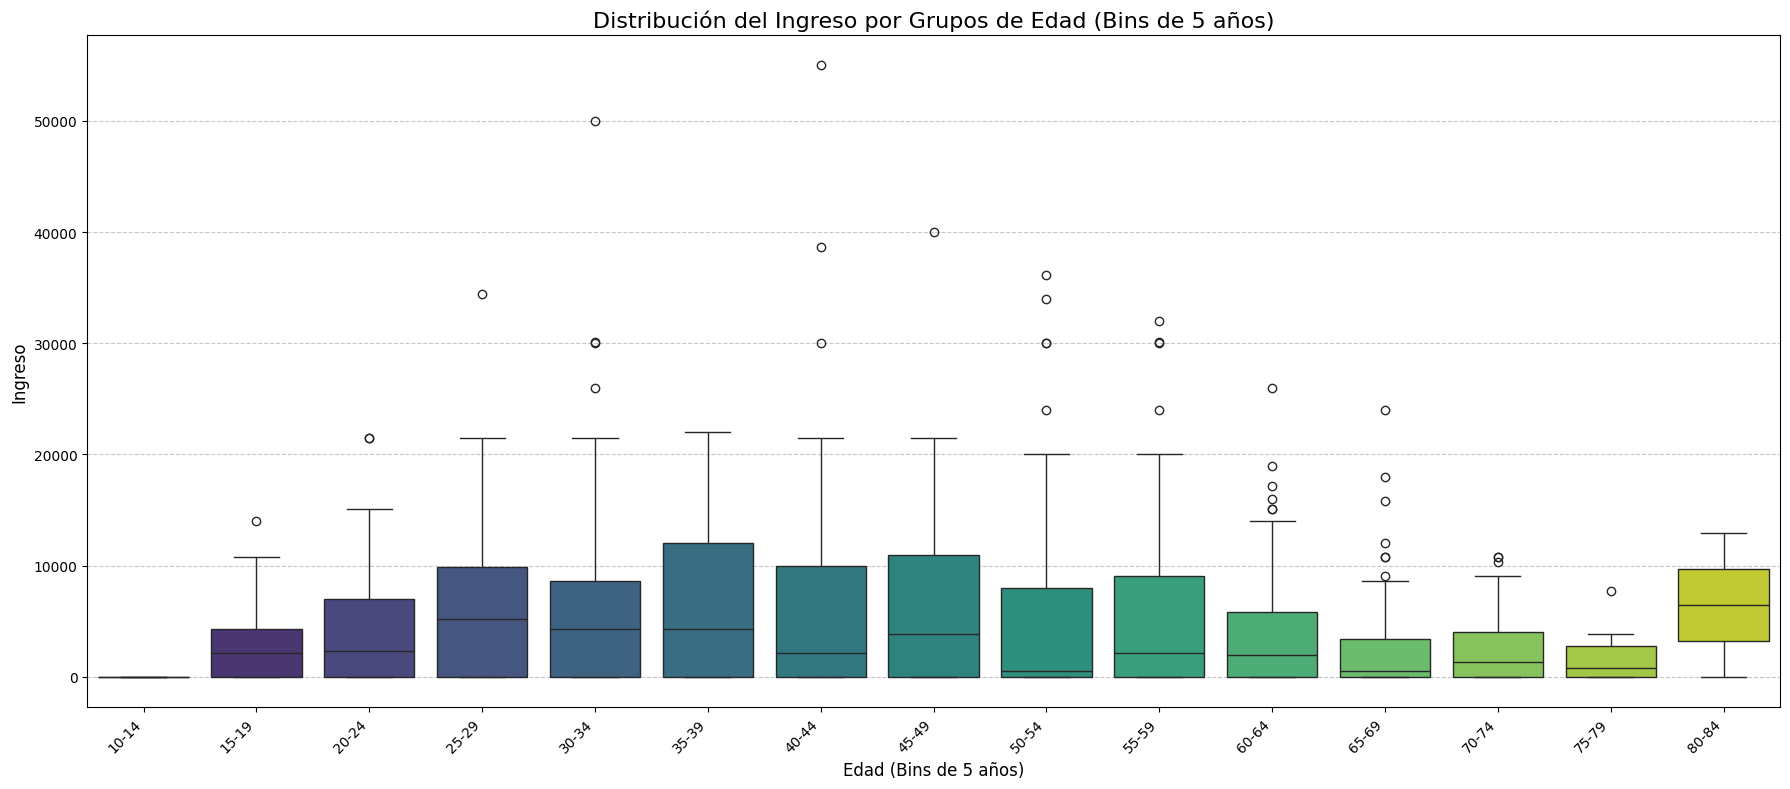

In [ ]:
plt.figure(figsize=(18, 8))
sns.boxplot(data=enoe, x='edad_binned', y='ingreso', palette='viridis', order=sorted(enoe['edad_binned'].dropna().astype(str).unique()))
plt.title('Distribución del Ingreso por Grupos de Edad (Bins de 5 años)', fontsize=16)
plt.xlabel('Edad (Bins de 5 años)', fontsize=12)
plt.ylabel('Ingreso', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

El análisis de Dependencia Parcial (PDP) derivado del modelo de clasificación revela que la edad opera como un predictor fundamental del nivel salarial más alto, exhibiendo un comportamiento no lineal en forma de U invertida. Manteniendo constantes el resto de las variables sociodemográficas y laborales, el modelo identifica que la franja etaria entre los 40 y 45 años constituye el punto de máxima probabilidad (peak dependence) para percibir ingresos de nivel superior.

Este hallazgo empírico demuestra que el mercado laboral oaxaqueño penaliza estadísticamente tanto la falta de experiencia en la juventud como la edad avanzada, concentrando el máximo rendimiento salarial en la etapa de madurez profesional.